<a href="https://colab.research.google.com/github/edaska/Stochastic_Processes_-_Optimization_in_Machine_Learning/blob/main/lab8/Stochastic_Processes_%26_Optimization_in_Machine_Learning_(Lab_8_Q_Learning).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1>Q-Learning</h1>

<p>In this exercise, you will study the stochastic Q-Learning algorithm using the ready-made program provided.</p>

<p>This example presents a Q-Learning implementation for an autonomous taxi-driving scenario. In this problem, the taxi must satisfy the following requirements:</p>

<ul>
<li>Drop off the passenger at the correct destination.</li>
<li>Follow the shortest possible route.</li>
<li>Respect traffic rules and ensure passenger safety.</li>
</ul>

<p>The problem is defined in terms of rewards, states, and actions, as described below.</p>

<h4>Reward</h4>
<ul>
<li>The taxi receives the highest reward when it successfully drops off the passenger at the correct destination.</li>
<li>A penalty is applied if the taxi drops off the passenger at the wrong location.</li>
<li>A small penalty is applied at each step to encourage the taxi to reach the destination as quickly as possible.</li>
</ul>

<p>These reward rules can be summarized as follows: the taxi receives <b>20 points</b> when it successfully drops off the passenger at the correct destination and loses <b>1 point</b> for each time step taken. In addition, a <b>10-point penalty</b> is applied when the taxi attempts to pick up or drop off the passenger at an incorrect location.</p>

<h4>Number of States</h4>
<img src="https://storage.googleapis.com/lds-media/images/Reinforcement_Learning_Taxi_Env.width-1200.png">

<p>In this example, the taxi operates in a small <b>5 × 5 grid</b>. The environment also includes <b>4 possible destination locations</b> and <b>5 possible passenger locations</b>.</p>

<p>Therefore, the total number of possible states is calculated as:</p>

<p><b>5 × 5 × 5 × 4 = 500 states</b></p>

<p>Each state represents a different combination of the taxi's position, the passenger's location, and the passenger's destination.</p>

<h4>Number of Actions</h4>

<p>The taxi can choose from <b>six possible actions</b>:</p>

<ul>
<li><b>0</b> = Move South</li>
<li><b>1</b> = Move North</li>
<li><b>2</b> = Move East</li>
<li><b>3</b> = Move West</li>
<li><b>4</b> = Pick up the passenger</li>
<li><b>5</b> = Drop off the passenger</li>
</ul>

<p>However, not every action is valid in every state. For example, if the taxi is next to a wall or obstacle in the grid, it may not be able to move in that direction. Similarly, pickup and drop-off actions are only appropriate when the taxi is at the correct location.</p>





<p>Before continuing with the exercise, answer the following questions:</p>
<ul>
<li> Is Q-Learning a model-free or model-based reinforcement learning algorithm? Justify your answer by explaining whether the agent needs prior knowledge of the environment’s transition probabilities and reward function.</li>

Q-Learning is a model-free reinforcement learning algorithm. This means that the agent does not need prior knowledge of the environment’s transition probabilities $p_{ij}(a)$. It also does not need to know the expected reward or cost function in advance. Instead, the agent learns from experience: it takes an action, observes the next state and the immediate reward/cost, and then updates its estimate of the value of that state-action pair.

So, instead of using a known model of the environment, Q-Learning gradually builds knowledge through repeated interactions with the environment.

<li>Briefly describe the Q-Learning algorithm. In which problems do you think Reinforcement Learning is suitable as a learning approach? What is the main difference between the Q-Learning algorithm and the Policy Iteration and Value Iteration algorithms?</li>

Q-Learning is a model-free, off-policy reinforcement learning algorithm that estimates the value of each state-action pair. In the cost-minimization version used in the lecture, the update rule is:
$Q_{n+1}(i,a)=(1-η_n)Q_n(i,a)+η_n[g(i,a,j)+γJ_n(j)]$

where: $J_n(j)=\min\limits_{b \in A_j}Q_n(j,b)$

This means that when the agent is in state $i$, takes action $a$, pays an immediate cost $g(i,a,j)$, and moves to state $j$, it updates $Q(i,a)$ using both the observed immediate cost and the best estimated future cost from state $j$.

Reinforcement Learning is suitable for problems where an agent must learn by interacting with an environment, especially when the transition probabilities are unknown.

The main difference from Policy Iteration and Value Iteration is that those are model-based dynamic programming methods: they require knowledge of the transition probabilities $p_{ij}(a)$ and expected costs/rewards. Q-Learning, instead, learns directly from sampled trajectories and observed rewards/costs, without requiring the full environment model.



<p>Next, you need to load the <i>gymnasium</i> library as well as the relevant dataset.</p>

In [1]:
!pip install gymnasium

array([[[110, 109, 106],
        [110, 109, 106],
        [124, 122, 122],
        ...,
        [108, 111, 109],
        [108, 111, 109],
        [118, 119, 119]],

       [[110, 109, 106],
        [110, 109, 106],
        [124, 122, 122],
        ...,
        [108, 111, 109],
        [108, 111, 109],
        [118, 119, 119]],

       [[114, 116, 115],
        [114, 116, 115],
        [126, 127, 126],
        ...,
        [112, 113, 111],
        [112, 113, 111],
        [118, 117, 115]],

       ...,

       [[116, 115, 116],
        [116, 115, 116],
        [106, 107, 108],
        ...,
        [113, 115, 114],
        [113, 115, 114],
        [117, 114, 117]],

       [[116, 115, 116],
        [116, 115, 116],
        [106, 107, 108],
        ...,
        [113, 115, 114],
        [113, 115, 114],
        [117, 114, 117]],

       [[115, 112, 112],
        [115, 112, 112],
        [119, 119, 117],
        ...,
        [123, 119, 118],
        [123, 119, 118],
        [114, 114, 117]]], dtype=uint8)
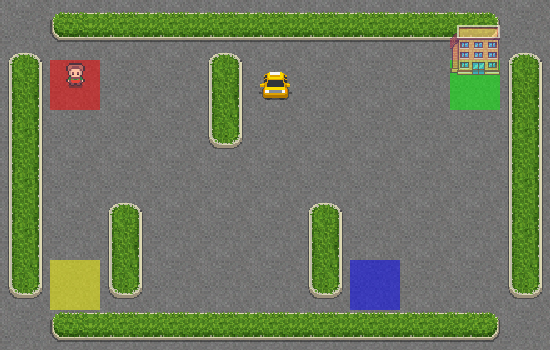

In [2]:
import gymnasium as gym

env = gym.make("Taxi-v4", render_mode="rgb_array")
# Reset the environment to start
env.reset()

# Render the initial state
env.render()

Action Space Discrete(6)
State Space Discrete(500)


array([[[110, 109, 106],
        [110, 109, 106],
        [124, 122, 122],
        ...,
        [108, 111, 109],
        [108, 111, 109],
        [118, 119, 119]],

       [[110, 109, 106],
        [110, 109, 106],
        [124, 122, 122],
        ...,
        [108, 111, 109],
        [108, 111, 109],
        [118, 119, 119]],

       [[114, 116, 115],
        [114, 116, 115],
        [126, 127, 126],
        ...,
        [112, 113, 111],
        [112, 113, 111],
        [118, 117, 115]],

       ...,

       [[116, 115, 116],
        [116, 115, 116],
        [106, 107, 108],
        ...,
        [113, 115, 114],
        [113, 115, 114],
        [117, 114, 117]],

       [[116, 115, 116],
        [116, 115, 116],
        [106, 107, 108],
        ...,
        [113, 115, 114],
        [113, 115, 114],
        [117, 114, 117]],

       [[115, 112, 112],
        [115, 112, 112],
        [119, 119, 117],
        ...,
        [123, 119, 118],
        [123, 119, 118],
        [114, 114, 117]]], dtype=uint8)
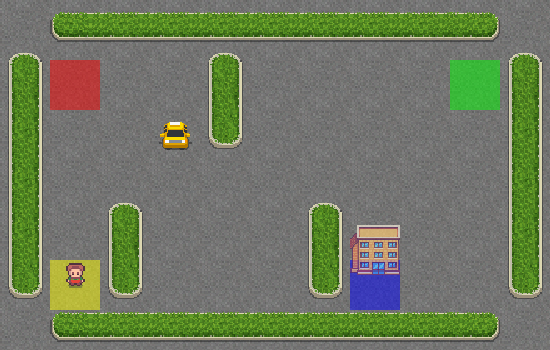

In [3]:
env.reset() # reset environment to a new, random state

print("Action Space {}".format(env.action_space))
print("State Space {}".format(env.observation_space))

# Render the initial state
env.render()

<p>Below, we define the taxi’s coordinates, the passenger’s location, and the destination point.</p>

In [4]:
taxi = env.unwrapped            # the actual TaxiEnv


state = taxi.encode(3, 1, 2, 0) # (taxi row, taxi column, passenger index, destination index)
print("State:", state)

taxi.s = state

State: 328


<p>Below is the reward matrix for the state we defined in the previous step.</p>

In [5]:
taxi.P[328]

{0: [(1.0, 428, -1, False)],
 1: [(1.0, 228, -1, False)],
 2: [(1.0, 348, -1, False)],
 3: [(1.0, 328, -1, False)],
 4: [(1.0, 328, -10, False)],
 5: [(1.0, 328, -10, False)]}

<p>We run our example without using Q-Learning.</p>

<ul><li>Are the results satisfactory? How would the use of Q-Learning help us?</li></ul>

The results are not satisfactory. The taxi eventually completes the task, but it needs too many timesteps and receives many penalties because it chooses actions randomly. Therefore, the agent has no strategy and does not learn from previous mistakes.

Q-Learning helps because it updates each state-action value using the observed immediate reward/cost and the best estimated future value from the next state, even if the action followed during exploration was not the greedy optimal action.

In [6]:
taxi.s = 328  # set environment to illustration's state

epochs = 0
penalties, reward = 0, 0

frames = [] # for animation

done = False

while not done:
    action = taxi.action_space.sample()
    state, reward, done, truncated, info = env.step(action)

    if reward == -10:
        penalties += 1

    # Put each rendered frame into dict for animation
    frames.append({
        'frame': taxi.render(),
        'state': state,
        'action': action,
        'reward': reward
        }
    )

    epochs += 1


print("Timesteps taken: {}".format(epochs))
print("Penalties incurred: {}".format(penalties))

Timesteps taken: 3334
Penalties incurred: 1083


<p>Now we will try to solve our problem using Q-Learning.</p>

<ul><li>What is the role of the parameters α and γ in Q-Learning? What would be the effect of setting both parameters equal to 1?</li></ul>

The role of the parameters $α$ and $γ$ in Q-Learning is:
- $α$ (Learning Rate Parameter): $α$ is a positive constant used to define the decreasing learning parameter $η_n$ over time, utilizing the formula $η_n = α / (β + n)$. The learning parameter itself determines how much the newly observed costs correct the older Q-factor estimates.
- $γ$ (Discounting Factor): $η$ acts as a weight for future expected costs or rewards.

If both $α$ and $γ$ are set equal to $1$, the agent completely replaces the old Q-value with the new estimate and gives no discount to future rewards/costs. In other words, the update becomes fully dependent on the current observed reward/cost plus the estimated future value.

In [7]:
import numpy as np
q_table = np.zeros([taxi.observation_space.n, taxi.action_space.n])

In [8]:
%%time
"""Training the agent"""

import random
from IPython.display import clear_output

# Hyperparameters
alpha = 0.1
gamma = 0.6
epsilon = 0.1

# For plotting metrics
all_epochs = []
all_penalties = []

for i in range(1, 100001):
    state, _ = taxi.reset()

    epochs, penalties, reward, = 0, 0, 0
    done = False

    while not done:
        if random.uniform(0, 1) < epsilon:
            action = env.action_space.sample() # Explore action space
        else:
            action = np.argmax(q_table[state]) # Exploit learned values

        next_state, reward, done, truncated, info = taxi.step(action)

        old_value = q_table[state, action]
        next_max = np.max(q_table[next_state])

        new_value = (1 - alpha) * old_value + alpha * (reward + gamma * next_max)
        q_table[state, action] = new_value

        if reward == -10:
            penalties += 1

        state = next_state
        epochs += 1

    if i % 100 == 0:
        clear_output(wait=True)
        print(f"Episode: {i}")

print("Training finished.\n")

Episode: 100000
Training finished.

CPU times: user 1min 16s, sys: 9.42 s, total: 1min 25s
Wall time: 1min 24s


In [9]:
q_table[328]

array([ -2.38828864,  -2.27325184,  -2.41147464,  -2.35790105,
       -10.20201257, -10.8092702 ])

In [10]:
"""Evaluate agent's performance after Q-learning"""

total_epochs, total_penalties = 0, 0
episodes = 100

for _ in range(episodes):
    state, _ = taxi.reset()
    epochs, penalties, reward = 0, 0, 0

    done = False

    while not done:
        action = np.argmax(q_table[state])
        state, reward, done, truncated, info = env.step(action)

        if reward == -10:
            penalties += 1

        epochs += 1

    total_penalties += penalties
    total_epochs += epochs

print(f"Results after {episodes} episodes:")
print(f"Average timesteps per episode: {total_epochs / episodes}")
print(f"Average penalties per episode: {total_penalties / episodes}")

Results after 100 episodes:
Average timesteps per episode: 12.75
Average penalties per episode: 0.0


<p>Evaluate and compare the two algorithms using the following performance metrics:</p>

<ul>
<li>Average number of penalties per episode</li>
<li>Average number of steps required to complete a trip</li>
<li>Average reward obtained per move</li>
</ul>

<p>Run the comparison over <b>100 episodes</b>.</p>

In [14]:
total_epochs = 0
total_penalties = 0
total_rewards = 0

episodes = 100000

for _ in range(episodes):
    state, _ = env.reset()

    epochs = 0
    penalties, reward = 0, 0

    done = False
    truncated = False

    while not (done or truncated):
        action = taxi.action_space.sample()
        state, reward, done, truncated, info = env.step(action)

        if reward == -10:
            penalties += 1

        total_rewards += reward
        epochs += 1

    total_epochs += epochs
    total_penalties += penalties

print("Average timesteps per episode: {}".format(total_epochs / episodes))
print("Average penalties incurred: {}".format(total_penalties / episodes))
print("Average reward per move: {}".format(total_rewards / total_epochs))

Average timesteps per episode: 196.55962
Average penalties incurred: 63.93221
Average reward per move: -3.922238402780795


In [17]:
"""Evaluate agent's performance after Q-learning"""

total_epochs, total_penalties, total_rewards = 0, 0, 0
episodes = 100000

for _ in range(episodes):
    state, _ = taxi.reset()
    epochs, penalties, reward = 0, 0, 0

    done = False

    while not done:
        action = np.argmax(q_table[state])
        state, reward, done, truncated, info = env.step(action)

        if reward == -10:
            penalties += 1

        epochs += 1

    total_penalties += penalties
    total_epochs += epochs
    total_rewards += reward

print(f"Results after {episodes} episodes:")
print(f"Average timesteps per episode: {total_epochs / episodes}")
print(f"Average penalties per episode: {total_penalties / episodes}")
print("Average reward per move: {}".format(total_rewards / total_epochs))

Results after 100000 episodes:
Average timesteps per episode: 13.07175
Average penalties per episode: 0.0
Average reward per move: 1.5300170214393636


Evaluate and compare the two algorithms using the following performance metrics:

At 100 episodes:
Average number of penalties per episode =
Average number of steps required to complete a trip
Average reward obtained per move

